In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, NNConv, CGConv, global_max_pool, GCNConv, GATConv, GATv2Conv
from torch_geometric.nn import SAGPooling, ASAPooling

from pymatgen.core import Structure, PeriodicSite, DummySpecie, Composition, Element
from pymatgen.core.periodic_table import Element as PMGElement
from pymatgen.analysis.local_env import MinimumDistanceNN, CrystalNN, VoronoiNN
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

import graphy_gnn

/home/amutua/inverse/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Prep

This involves converting the crystal structures into graphs where each atom represents a node and each site's features are the node features. 

The graph also has edges which represent the bonds and the edge features are the relationships between two sites. 

There are also global features which are the universal features for the whole structure.

In [2]:
if not os.path.exists(f"Final_Dataset/gnn graphs/train_graphs.pt"):
    comb_df = pd.read_csv("Final_Dataset/combined/combined_data.csv")

    comb_df = comb_df[comb_df["defect_sites"] != 1]
    
    # Split the data
    train_set, test_set = train_test_split(comb_df, test_size=0.2, stratify=comb_df['strata'], random_state=42)
    test_set, val_set = train_test_split(test_set, test_size=0.5, random_state=42)

    # Create graphs for each set
    train_graphs = graphy_gnn.fast_grapy(train_set)
    val_graphs = graphy_gnn.fast_grapy(val_set)
    test_graphs = graphy_gnn.fast_grapy(test_set)

    # Save graphs
    torch.save(train_graphs, "Final_Dataset/gnn graphs/train_graphs.pt")
    torch.save(val_graphs, "Final_Dataset/gnn graphs/val_graphs.pt")
    torch.save(test_graphs, "Final_Dataset/gnn graphs/test_graphs.pt")

else:
    train_graphs = torch.load("Final_Dataset/gnn graphs/train_graphs.pt", weights_only=False)
    val_graphs = torch.load("Final_Dataset/gnn graphs/val_graphs.pt", weights_only=False)
    test_graphs = torch.load("Final_Dataset/gnn graphs/test_graphs.pt", weights_only=False)

In [3]:
# Find the graph where the edge features has shape 0 and remove them

def remove_1_defect_graphs(graphs):
    unwanted = []
    for i, data in enumerate(graphs):
        if data.edge_attr.shape[0] == 0:
            unwanted.append(i)

    new_graphs = [data for i, data in enumerate(graphs) if i not in unwanted]
    return new_graphs

new_train_graphs = remove_1_defect_graphs(train_graphs)
new_val_graphs = remove_1_defect_graphs(val_graphs)
new_test_graphs = remove_1_defect_graphs(test_graphs)

In [4]:
# Add ids and ratios in the data

mean_en = []
idss = []

look_dict = {
    "GaSe": ["In", "S"],
    "InSe": ["Ga", "S"],
    "BN"  : ["C"],
    "P"   : ["N"],
    "WSe2": ["Mo", "S"],
    "MoS2": ["W", "Se"],
    }

for i in look_dict.keys():
    pristine_sample = Structure.from_file(f"Final_Dataset/ref_cifs/high_{i}.cif")
    sample_elements = pristine_sample.composition.elements

    sample_X = [e.X for e in sample_elements]

    sample_en_mean = float(np.round(np.mean(sample_X), 2))
    mean_en.append(sample_en_mean)

    # Get Ids
    possible_elements = look_dict.get(i)
    the_ids = [Element(el).Z for el in possible_elements]
    idss.append([0] + the_ids)

look_up_dict = dict(zip(mean_en, idss))

def get_ids_ratios(graphs):
    for data in graphs:

        # Host average electronegativity
        host_avg_en = np.round(torch.round(data.u[..., 2], decimals=2).item(), 2)
        # idx+=1
        # print(idx)
        # print(host_avg_en)

        ids = look_up_dict.get(host_avg_en)
        # print(ids)

        # Defect types
        defects = data.x[:, 6].cpu().numpy()

        # Count occurrences of each id
        num_defects = [np.sum(defects == item) for item in ids]

        total = sum(num_defects)

        ratios = [count / total for count in num_defects]

        data.ids=torch.tensor(ids, dtype=torch.long)
        data.ratios=torch.tensor(ratios, dtype=torch.float)

    return graphs

new_train_graphs = get_ids_ratios(new_train_graphs)
new_val_graphs = get_ids_ratios(new_val_graphs)
new_test_graphs = get_ids_ratios(new_test_graphs)

/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 32 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 24 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 48 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


In [5]:
for i in new_train_graphs:
    print(i)
    break

Data(x=[3, 27], edge_index=[2, 3], edge_attr=[3, 14], y=[1], u=[1, 14], fe=[1], ids=[3], ratios=[3])


In [6]:
train_loader = DataLoader(new_train_graphs, batch_size=1, shuffle=True)
val_loader = DataLoader(new_val_graphs, batch_size=1, shuffle=False)
test_loader = DataLoader(new_test_graphs, batch_size=1, shuffle=False)

In [7]:
# Use data size to determine model architecture
NODE_DIM =new_train_graphs[0].x.shape[1] # 27
EDGE_DIM =new_train_graphs[0].edge_attr.shape[1] # 14
HIDDEN_DIM = 128
EMBED_DIM = 64
U_DIM =new_train_graphs[0].u.shape[1] # 14

# The GNN Model

In [8]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from tqdm.auto import tqdm

def evaluate(model, loader, loss_fn, device):
    model.eval()
    eval_loss = 0
    with torch.no_grad():
        for data in tqdm(loader, leave=False):
            data = data.to(device)
            out = model(data)
            if torch.isnan(out):
                print("Found a NaN value")
                break
            loss = loss_fn(out, data.y)

            eval_loss += loss.item() * data.num_graphs
    return eval_loss / len(loader.dataset)

def train(model, train_loader, loss_fn, device, optimizer):
    model.train()
    train_loss = 0


    for data in tqdm(train_loader, leave=False):
        optimizer.zero_grad()

        data = data.to(device)
        out = model(data)
        if torch.isnan(out):
            print("Found a NaN value")
            break
        loss = loss_fn(out, data.y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()
        train_loss += loss.item() * data.num_graphs

    return train_loss / len(train_loader.dataset)

def predict(model, loader, device, visualize=False):
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for data in tqdm(loader, leave=False):
            data = data.to(device)
            out = model(data)
            if torch.isnan(out):
                print("Found a NaN value")
                break

            predictions.append(out.cpu().numpy())

            # Only collect targets if they exist
            if hasattr(data, "y") and data.y is not None:
                actuals.append(data.y.cpu().numpy())

    if actuals:
        actuals = np.concatenate(actuals, axis=0).flatten()
    else:
        actuals = None

    predictions = np.concatenate(predictions, axis=0).flatten()

    '''return predictions, actuals

    prediction = np.concatenate(predictions, axis=0).flatten()
    actual = np.concatenate(actuals, axis=0).flatten()'''

    if visualize:
        fig, axs = plt.subplots(3, 1, figsize=(10, 15))

        # model values
        predicted_values = predictions
        actual_values = actuals
        residuals = actual_values - predicted_values


        axs[0].scatter(actual_values, predicted_values )
        axs[0].plot(actual_values, actual_values, c="black")
        axs[0].set_xlabel('Actual Band Gaps(eV)')
        axs[0].set_ylabel('Predicted Band Gaps(eV)')
        axs[0].set_title('Actual vs Predicted Band Gap Values')
        axs[0].legend()

        axs[1].plot(actual_values[100:150], label='Actual Values', marker='o')
        axs[1].plot(predicted_values[100:150], label='Predicted Values', marker='o')
        axs[1].set_xlabel('Samples')
        axs[1].set_ylabel('Band gap(eV)')
        axs[1].set_title('Actual vs Predicted Band Gap Values')
        axs[1].legend()

        axs[2].scatter(predicted_values, residuals )
        axs[2].axhline(0, color='red', linestyle='--')
        axs[2].set_xlabel('Predicted Band Gaps(eV)')
        axs[2].set_ylabel('Residuals (Actual - Predicted)')
        axs[2].set_title('Residual Plot')

        plt.tight_layout()
        plt.show()

    return predictions, actuals

In [9]:
# Loss functions

class LogCoshLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, input, target):
        ey_t = input-target
        return torch.mean(torch.log(torch.cosh(ey_t + 1e-12)))


class RelativeMSELoss(nn.Module):
    def __inti__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        return torch.mean(((y_pred-y_true)/ (y_true + 1e-8)) ** 2)


class SMAPELoss(nn.Module):
    def __inti__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        numerator = torch.abs(y_pred - y_true)
        denominator = (torch.abs(y_true) + torch.abs(y_pred))/2.0 + 1e-8
        return torch.mean(numerator/denominator)

## Model 1

In [66]:
# Original Model
class GNNModel0(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim, embed_dim):
        super().__init__()
        # Edge NN maps edge_attr to weight matrix
        self.edge_nn = nn.Sequential(
            nn.Linear(edge_dim, 32),
            nn.ReLU(),
            nn.Linear(32, node_dim * hidden_dim)
        )

        self.element_embedding = nn.Embedding(118, embed_dim)

        self.conv1 = NNConv(node_dim, hidden_dim, self.edge_nn, aggr='mean')

        self.fc0 = nn.Linear(hidden_dim + embed_dim, 64)
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 1)

    def get_u(self, the_ids, the_ratios):
        emb = self.element_embedding(the_ids)
        weighted_emb = emb * the_ratios.unsqueeze(1)
        return weighted_emb.sum(dim=0)

    def forward(self,data):
        x = F.relu(self.conv1(data.x, data.edge_index, data.edge_attr))
        x = global_mean_pool(x, data.batch)
        idss = data.the_ids.squeeze(0)
        ratioss = data.the_ratios.squeeze(0)
        global_attr = self.get_u(idss.to(self.element_embedding.weight.device),
                                 ratioss.to(self.element_embedding.weight.device)
                                 ).expand(x.size(0), -1)

        x = torch.cat([x, global_attr], dim=1)
        x = F.relu(self.fc0(x))
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

  0%|          | 0/11886 [00:00<?, ?it/s]/home/amutua/inverse/lib/python3.10/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 001, Train Loss: 0.3165, Val Loss: 0.3089


Epoch 002, Train Loss: 0.3156, Val Loss: 0.3087


Epoch 003, Train Loss: 0.3157, Val Loss: 0.3090


Epoch 004, Train Loss: 0.3155, Val Loss: 0.3091


...

Epoch 009, Train Loss: 0.3156, Val Loss: 0.3095


Epoch 010, Train Loss: 0.3156, Val Loss: 0.3091


Epoch 011, Train Loss: 0.3156, Val Loss: 0.3090


Epoch 012, Train Loss: 0.3157, Val Loss: 0.3087


Test Loss: 0.3102


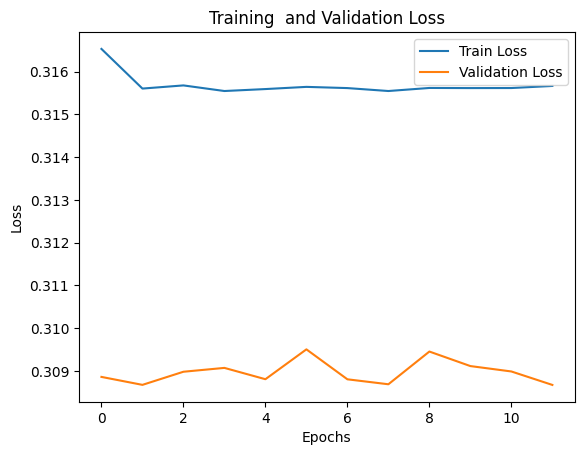

In [10]:
class Node_Model(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim):
        super().__init__()

        self.conv0 = GATv2Conv(node_dim, hidden_dim, edge_dim=edge_dim)
                
        self.conv1 = CGConv(hidden_dim, edge_dim, aggr='mean') # , batch_norm=True)
        self.normalize1 = nn.BatchNorm1d(hidden_dim)
        self.conv1_lin1 = nn.Linear(hidden_dim, 64)

        self.conv2 = CGConv(64, edge_dim, aggr='mean') # , batch_norm=True)
        self.normalize2 = nn.BatchNorm1d(64)
        self.conv2_lin2 = nn.Linear(64, 32)

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index,
            data.edge_attr, data.batch
        )
        x = F.relu(self.normalize1(self.conv0(x, edge_index, edge_attr)))
        
        x = F.relu(self.normalize1(self.conv1(x, edge_index, edge_attr)))
        x = F.relu(self.conv1_lin1(x))

        x = F.relu(self.normalize2(self.conv2(x, edge_index, edge_attr)))
        x = F.relu(self.conv2_lin2(x))

        x = global_mean_pool(x, batch)

        return x # [1,32]

class Global_Model(nn.Module):
    def __init__(self, u_dim):
        super().__init__()

        self.seq_u_1 = nn.Sequential(
            nn.Linear(1, 8), nn.ReLU(), 
            nn.Linear(8, 16), nn.ReLU(),
        )

        self.seq_u_all = nn.Sequential(
            nn.Linear(u_dim * 16, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32)
        )

    def forward(self, data):
        u = data.u

        all_u = []

        for i in u[0]:
            i = torch.tensor([i]).unsqueeze(1).to(device=u.device)
            u_1 = self.seq_u_1(i)
            all_u.append(u_1)

        all_u = torch.cat(all_u, dim=1)# .to(device=u.device)
        out_u = self.seq_u_all(all_u)

        return out_u

class Ids_Ratios_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.ids_embedding = nn.Embedding(119, 32, max_norm=1)
        self.pad_embed = nn.Parameter(torch.randn(32))

        self.ids_ratios_embed = nn.Sequential(
            nn.Linear(32*3, 32*2), nn.ReLU(), 
            nn.Linear(32*2, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU()
        )

    def forward(self, data):
        ids, ratios = data.ids, data.ratios

        ids_embed = self.ids_embedding(ids)
        weighted_emb = ids_embed * ratios.unsqueeze(1)
        
        
        if weighted_emb.shape[0] == 2:
            # Add padding
            to_add = self.pad_embed.unsqueeze(0) # .repeat(1, 1)
            
            weighted_emb = torch.cat([weighted_emb, to_add], dim=0)

        weighted_emb = weighted_emb.flatten().unsqueeze(0) # [1,128]

        out_ids_ratios = self.ids_ratios_embed(weighted_emb) # [1,16]

        return out_ids_ratios # [1,16]

class Combined_Model(nn.Module):
    def __init__ (self, node_dim, edge_dim, u_dim, hidden_dim):
        super().__init__()
        self.for_nodes = Node_Model(node_dim, edge_dim, hidden_dim)
        self.for_global = Global_Model(u_dim)
        self.for_ids_ratios = Ids_Ratios_Model()

        # Combine them all

        self.combined = nn.Sequential(
            nn.Linear(80, 128), nn.ReLU(), nn.Dropout(), 
            nn.Linear(128, 256), nn.ReLU(), nn.Dropout(), 
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(), 
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(), 
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(), 
            nn.Linear(32, 16), nn.ReLU(), nn.Dropout(), 
            nn.Linear(16, 8), nn.ReLU(), nn.Dropout(), 
            nn.Linear(8, 4), nn.ReLU(), nn.Dropout(), 
            nn.Linear(4, 2), nn.ReLU(), nn.Dropout(), 
            nn.Linear(2, 1),    
        )

    def forward(self, data):
        nodes_out = self.for_nodes(data)
        globals_out = self.for_global(data)
        ids_ratios_out = self.for_ids_ratios(data)

        the_combined = torch.cat([nodes_out, globals_out, ids_ratios_out], dim=1)

        output = self.combined(the_combined)
        return output
        
# PARAMETERIZE THE MODEL
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model1 = Combined_Model(NODE_DIM, EDGE_DIM, U_DIM, HIDDEN_DIM).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
loss_fn = nn.MSELoss()
# loss_fn = LogCoshLoss()
# loss_fn = RelativeWeightedLoss()
EPOCHS = 12

# TRAIN AND VALIDATE MODEL

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS+1):
    t_loss = train(model1, train_loader, loss_fn, device, optimizer)
    train_losses.append(t_loss)

    v_loss = evaluate(model1, val_loader, loss_fn, device)
    val_losses.append(v_loss)

    scheduler.step()
    print(f'Epoch {epoch:03d}, Train Loss: {t_loss:.4f}, Val Loss: {v_loss:.4f}')

test_loss = evaluate(model1, test_loader, loss_fn, device)
print(f'Test Loss: {test_loss:.4f}')


# VISUALIZE METRICS

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training  and Validation Loss')
plt.legend()
plt.show()

In [ ]:
class GNNModel1(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim, embed_dim, u_dim):
        super().__init__()
        # For the nodes and edges


        self.conv0 = GATv2Conv(node_dim, hidden_dim, edge_dim=edge_dim)
        
        self.conv1 = CGConv(hidden_dim, edge_dim, aggr='mean') # , batch_norm=True)
        self.normalize1 = nn.BatchNorm1d(hidden_dim)
        self.conv1_lin1 = nn.Linear(hidden_dim, 64)

        self.conv2 = CGConv(64, edge_dim, aggr='mean') # , batch_norm=True)
        self.normalize2 = nn.BatchNorm1d(64)
        self.conv2_lin2 = nn.Linear(64, 32)

        self.asappool = ASAPooling(32)

        self.lin3 = nn.Linear(32,16)
        self.lin4 = nn.Linear(16,1)
        

        # =============
        # Global attributes
        # self.global_embed = nn.Linear(u_dim, 32)

        # ================
        # Embedding
        # self.defect_embed = nn.Embedding(119, 16, max_norm=1) 
        # self.pad_embed = nn.Parameter(torch.randn(16))

        # ===============
        # Combine everything

        '''self.fc = nn.Sequential(
            nn.Linear(32 + 32 + 48, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

        # ================
        # From formation enenrgy to Band Gap Value
        self.fe_to_bgv = nn.Sequential(
            nn.Linear(1, 8), nn.ReLU(),
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(), 
            nn.Linear(8, 1), 
        )
        '''

    def forward(self, data):
        x, edge_index, edge_attr, batch, u, ids, ratios, fe = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
            data.ids,
            data.ratios, 
            data.fe
        )

        # =====================
        x = F.relu(self.normalize1(self.conv0(x, edge_index, edge_attr)))

        x = F.relu(self.normalize1(self.conv1(x, edge_index, edge_attr)))
        x = F.relu(self.conv1_lin1(x))

        x = F.relu(self.normalize2(self.conv2(x, edge_index, edge_attr)))
        x = F.relu(self.conv2_lin2(x))

        x= self.asappool(x, edge_index)
        print(x[0])
        

        x = F.relu(self.lin3(x[0]))
        x = F.relu(self.lin4(x))

        return x



        '''

        # =====================
        u = self.global_embed(u) # [1,64]

        # =====================

        ids_embed = self.defect_embed(ids) #[3, 16]
        weighted_emb = ids_embed * ratios.unsqueeze(1)

        if weighted_emb.shape[0] == 2:
            # Add padding
            to_add = self.pad_embed.unsqueeze(0) # .repeat(1, 1)
            
            weighted_emb = torch.cat([weighted_emb, to_add], dim=0)

        weighted_emb = weighted_emb.flatten().unsqueeze(0) # [1,48]

        # ========================
        # Combine everything

        x = torch.cat([x, u], dim=1) # [1,192]
        x = torch.cat([x,weighted_emb], dim=1) # [1,240]

        the_return = self.fc(x)
        # the_return = self.fe_to_bgv(the_return)'''

        # return the_return

# PARAMETERIZE THE MODEL
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model1 = GNNModel1(NODE_DIM, EDGE_DIM, HIDDEN_DIM, EMBED_DIM, U_DIM).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
loss_fn = nn.MSELoss()
# loss_fn = LogCoshLoss()
# loss_fn = RelativeWeightedLoss()
EPOCHS = 20

# TRAIN AND VALIDATE MODEL

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS+1):
    t_loss = train(model1, train_loader, loss_fn, device, optimizer)
    train_losses.append(t_loss)

    v_loss = evaluate(model1, val_loader, loss_fn, device)
    val_losses.append(v_loss)

    scheduler.step()
    print(f'Epoch {epoch:03d}, Train Loss: {t_loss:.4f}, Val Loss: {v_loss:.4f}')

test_loss = evaluate(model1, test_loader, loss_fn, device)
print(f'Test Loss: {test_loss:.4f}')


# VISUALIZE METRICS

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training  and Validation Loss')
plt.legend()
plt.show()

tensor([[0.0000, 0.2270, 0.0106, 0.0000, 0.0390, 0.2329, 0.0225, 0.0431, 0.0000,
         0.1798, 0.0253, 0.0212, 0.1819, 0.0000, 0.1783, 0.0420, 0.0470, 0.0000,
         0.0000, 0.0000, 0.0116, 0.0000, 0.0000, 0.0549, 0.0000, 0.0395, 0.0000,
         0.2099, 0.0033, 0.0000, 0.0000, 0.0349],
        [0.0000, 0.2897, 0.0070, 0.0000, 0.0260, 0.2731, 0.0150, 0.0287, 0.0000,
         0.1718, 0.0169, 0.0141, 0.1572, 0.0000, 0.1970, 0.0280, 0.0739, 0.0297,
         0.0000, 0.0000, 0.0078, 0.0000, 0.0000, 0.0793, 0.0000, 0.0373, 0.0000,
         0.2488, 0.0022, 0.0000, 0.0000, 0.0326],
        [0.0000, 0.0618, 0.0202, 0.0000, 0.0749, 0.1063, 0.0431, 0.0660, 0.0000,
         0.0758, 0.0486, 0.0406, 0.1291, 0.0000, 0.0253, 0.0562, 0.0431, 0.0000,
         0.0000, 0.0000, 0.0223, 0.0000, 0.0000, 0.0274, 0.0000, 0.0000, 0.0000,
         0.0898, 0.0000, 0.0000, 0.0000, 0.0351],
        [0.0000, 0.1930, 0.1325, 0.0364, 0.0183, 0.3330, 0.0105, 0.0200, 0.1335,
         0.2916, 0.0119, 0.0099, 0.1061,

RuntimeError: Boolean value of Tensor with more than one value is ambiguous

In [ ]:
(
    tensor([
        [
            0.0000, 0.1421, 0.0743, 0.0000, 0.0000, 0.3349, 0.0404, 0.0000, 0.0458,
            0.0000, 0.0000, 0.0738, 0.0000, 0.1903, 0.0000, 0.0000, 0.0998, 0.0000,
            0.0577, 0.0269, 0.2277, 0.0069, 0.3610, 0.1941, 0.0000, 0.0000, 0.0184,
            0.1647, 0.0615, 0.1512, 0.0904, 0.0000
        ],
        [
            0.0000, 0.0732, 0.3879, 0.0000, 0.0000, 0.3724, 0.1999, 0.1703, 0.2170,
            0.3348, 0.0288, 0.0380, 0.0000, 0.2197, 0.0736, 0.2502, 0.0514, 0.0000,
            0.0297, 0.0138, 0.1173, 0.2688, 0.1859, 0.1084, 0.0000, 0.1006, 0.0095,
            0.0849, 0.0778, 0.4294, 0.0466, 0.0000
        ],
        [
            0.0000, 0.0511, 0.2710, 0.0464, 0.0634, 0.2601, 0.1396, 0.2302, 0.1955,
            0.3306, 0.0201, 0.0265, 0.0000, 0.3304, 0.0514, 0.2280, 0.0359, 0.0327,
            0.1172, 0.2059, 0.3835, 0.2030, 0.1299, 0.1177, 0.0000, 0.0703, 0.1609,
            0.0593, 0.0544, 0.6269, 0.1113, 0.0232
        ],
        [
            0.0000, 0.0387, 0.2746, 0.0980, 0.0494, 0.1966, 0.1913, 0.1765, 0.3284,
            0.3240, 0.0152, 0.0201, 0.0000, 0.2600, 0.1259, 0.2547, 0.0272, 0.0294,
            0.0909, 0.2631, 0.3118, 0.2254, 0.0984, 0.0901, 0.0000, 0.0995, 0.1254,
            0.0449, 0.0795, 0.5900, 0.1023, 0.0263
        ]], device='cuda:0', grad_fn=<MulBackward0>), 
    tensor([
        [0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3],
        [1, 2, 3, 0, 2, 3, 0, 1, 3, 0, 1, 2]], device='cuda:0'), 
    None, 
    tensor([0, 0, 0, 0], device='cuda:0'), 
    tensor([0, 1, 2, 3], device='cuda:0')
)

/tmp/ipykernel_2539433/1309934916.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


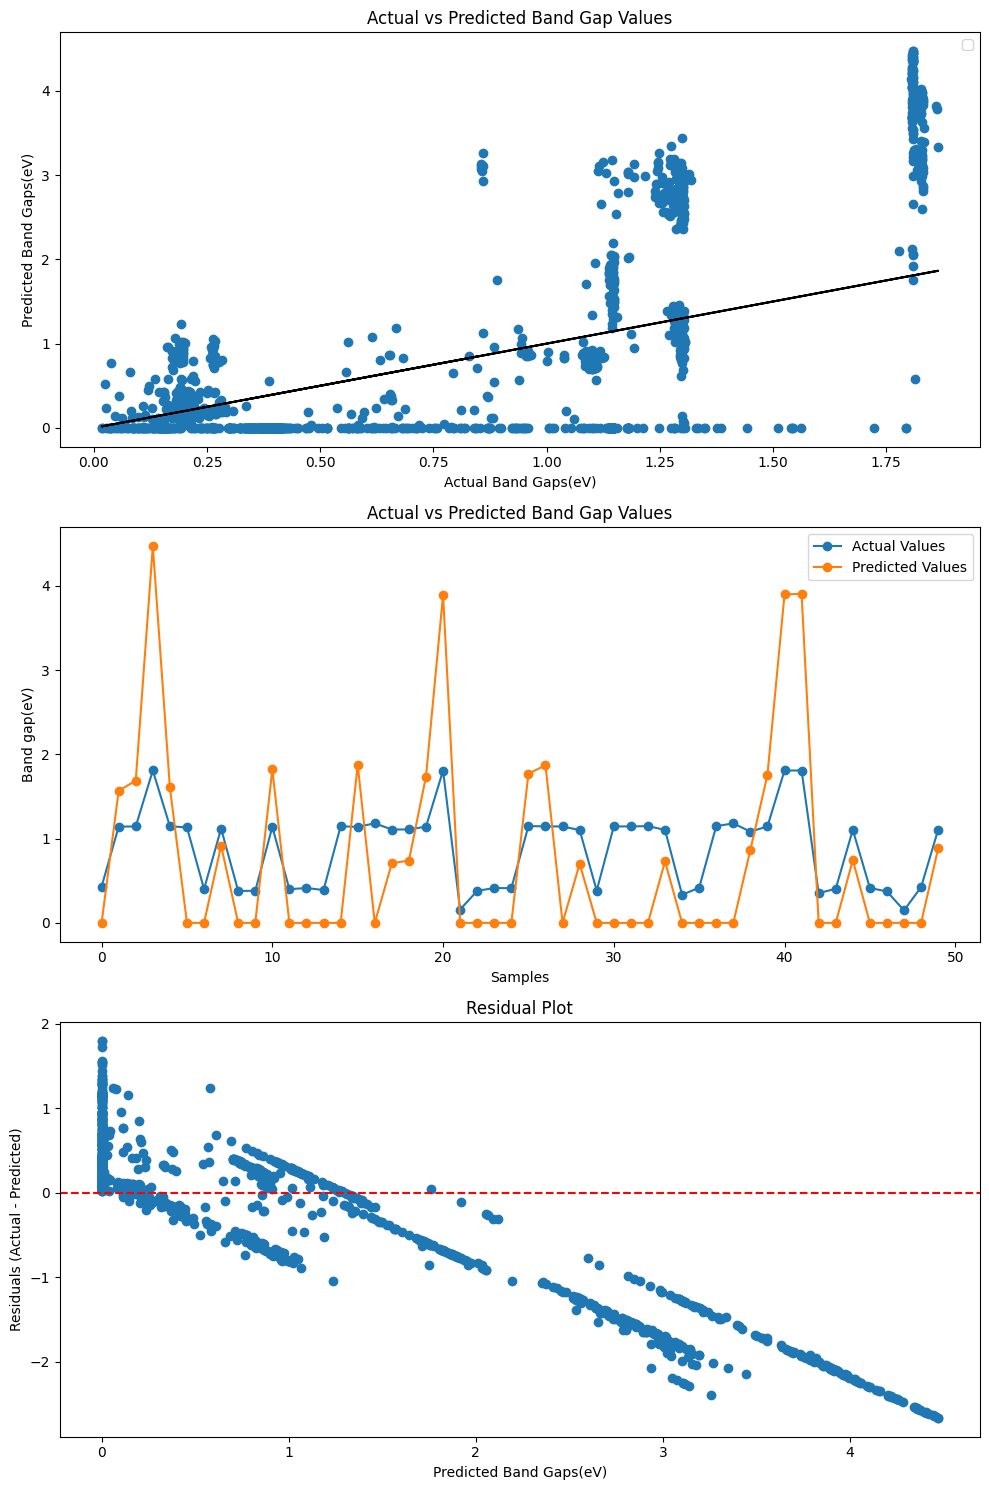

Mean Absolute Error: 0.6720
Mean Squared Error: 0.8552
R-squared: -1.7600


In [11]:
# Make Predictions
predicted, the_target = predict(model1, test_loader,device, visualize=True)

# ERROR ANALYSIS

mae = mean_absolute_error(the_target, predicted)
mse = mean_squared_error(the_target, predicted)
r2 = r2_score(the_target, predicted)

print(f'Mean Absolute Error: {mae:.4f}')
print(f'Mean Squared Error: {mse:.4f}')
print(f'R-squared: {r2:.4f}')


In [ ]:
class GNNModel1(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim, embed_dim, u_dim, max_defects=3, defect_embed_dim=16):
        super().__init__()
        self.max_defects = max_defects
        self.defect_embed_dim = defect_embed_dim

        self.conv0 = GATv2Conv(node_dim, hidden_dim, edge_dim=edge_dim)
        self.bn0 = nn.BatchNorm1d(hidden_dim)

        self.conv1 = CGConv(hidden_dim, edge_dim, aggr='mean')
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.conv1_lin1 = nn.Linear(hidden_dim, 64)

        self.conv2 = CGConv(64, edge_dim, aggr='mean')
        self.bn2 = nn.BatchNorm1d(64)
        self.conv2_lin2 = nn.Linear(64, 32)

        self.global_embed = nn.Linear(u_dim, 32)

        self.defect_embed = nn.Embedding(119, defect_embed_dim, max_norm=1)
        self.pad_embed = nn.Parameter(torch.randn(defect_embed_dim))

        self.fc = nn.Sequential(
            nn.Linear(32 + 32 + max_defects * defect_embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u, ids, ratios = (
            data.x, data.edge_index, data.edge_attr, data.batch,
            data.u, data.ids, data.ratios,
        )

        x = F.relu(self.bn0(self.conv0(x, edge_index, edge_attr)))
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_attr)))
        x = F.relu(self.conv1_lin1(x))
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_attr)))
        x = F.relu(self.conv2_lin2(x))

        x = global_mean_pool(x, batch)  # [batch_size, 32]

        u = self.global_embed(u)  # [batch_size, 32]

        defect_batch = data.ids # adjust name to whatever follow_batch produces
        batch_size = x.size(0)
        weighted_emb = torch.zeros(batch_size, self.max_defects, self.defect_embed_dim, device=x.device)
        ids_embed = self.defect_embed(ids) * ratios.unsqueeze(1)  # [num_defects_total, 16]
        for b in range(batch_size):
            mask = defect_batch == b
            emb_b = ids_embed[mask]
            n = emb_b.size(0)
            if n >= self.max_defects:
                weighted_emb[b] = emb_b[: self.max_defects]
            else:
                weighted_emb[b, :n] = emb_b
                weighted_emb[b, n:] = self.pad_embed.unsqueeze(0)

        weighted_emb = weighted_emb.flatten(start_dim=1)  # [batch_size, max_defects*16]

        x = torch.cat([x, u, weighted_emb], dim=1)
        return self.fc(x)

# PARAMETERIZE THE MODEL
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model1 = GNNModel1(NODE_DIM, EDGE_DIM, HIDDEN_DIM, EMBED_DIM, U_DIM).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
loss_fn = nn.MSELoss()
# loss_fn = LogCoshLoss()
# loss_fn = RelativeWeightedLoss()
EPOCHS = 20

# TRAIN AND VALIDATE MODEL

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS+1):
    t_loss = train(model1, train_loader, loss_fn, device, optimizer)
    train_losses.append(t_loss)

    v_loss = evaluate(model1, val_loader, loss_fn, device)
    val_losses.append(v_loss)

    scheduler.step()
    print(f'Epoch {epoch:03d}, Train Loss: {t_loss:.4f}, Val Loss: {v_loss:.4f}')

test_loss = evaluate(model1, test_loader, loss_fn, device)
print(f'Test Loss: {test_loss:.4f}')


# VISUALIZE METRICS

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training  and Validation Loss')
plt.legend()
plt.show()

/tmp/ipykernel_2165925/1249843317.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


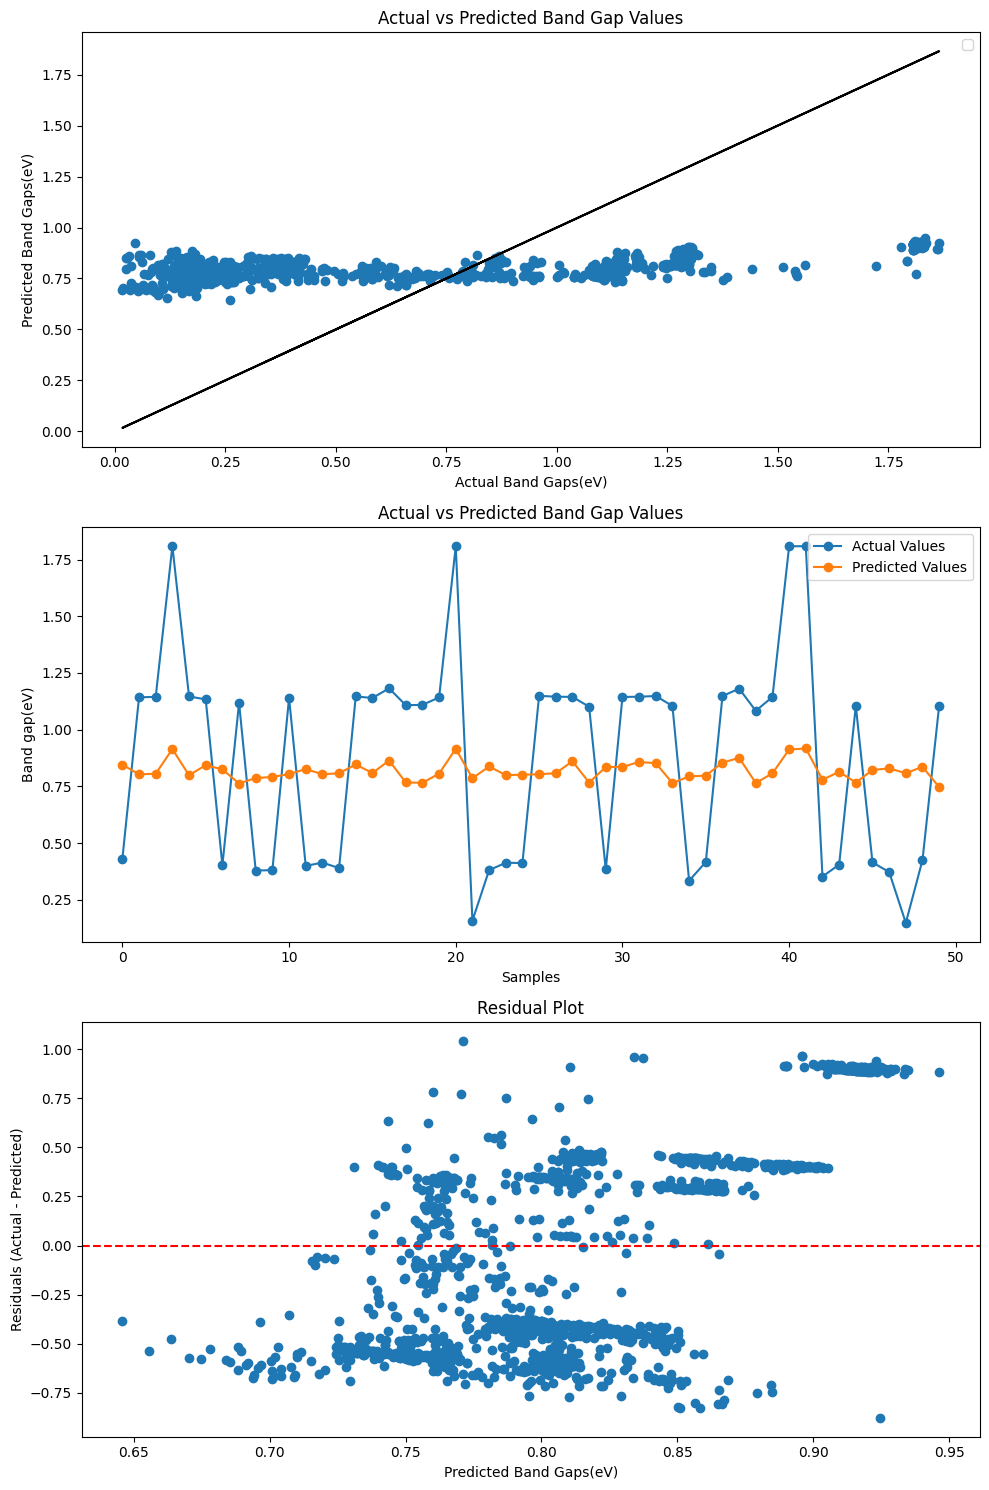

NameError: name 'prediction' is not defined

In [68]:
# Make Predictions
predicted, the_target = predict(model1, test_loader,device, visualize=True)

# ERROR ANALYSIS

mae = mean_absolute_error(the_target, predicted)
mse = mean_squared_error(the_target, predicted)
r2 = r2_score(the_target, predicted)

print(f'Mean Absolute Error: {mae:.4f}')
print(f'Mean Squared Error: {mse:.4f}')
print(f'R-squared: {r2:.4f}')


In [ ]:
# Save the model
path_file = "Final_Dataset/gnn models/GNNModel1.pth"
torch.save(model1.state_dict(), path_file)

## Model 2

In [ ]:
class GNNModel2(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, u_dim=U_DIM):
        super().__init__()

        # For the edges
        self.edge_nn = nn.Sequential(
            nn.Linear(edge_dim, 64),
            nn.ReLU(),
            nn.Linear(64, node_dim * hidden_dim)
        )

        self.conv1 = NNConv(node_dim, hidden_dim, self.edge_nn, aggr='mean')

        # self.conv1 = CGConv(hidden_dim, hidden_dim, aggr='mean')
        self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean')

        self.global_embed = nn.Linear(u_dim, embed_dim)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)

        u = self.global_embed(u)

        x = torch.cat([x, u], dim=1)
        the_return = self.fc(x)
        return the_return


train_losses = []
val_losses = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model2 = GNNModel2().to(device)
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
loss_fn = LogCoshLoss()
EPOCHS = 20

for epoch in range(1, EPOCHS+1):
    t_loss = train(model2, train_loader, loss_fn, device, optimizer)
    train_losses.append(t_loss)

    v_loss = evaluate(model2, val_loader, loss_fn, device)
    val_losses.append(v_loss)

    scheduler.step()
    print(f'Epoch {epoch:03d}, Train Loss: {t_loss:.4f}, Val Loss: {v_loss:.4f}')

test_loss = evaluate(model2, test_loader, loss_fn, device)
print(f'Test Loss: {test_loss:.4f}')

# Visualize metrics
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training  and Validation Loss')
plt.legend()
plt.show()

In [ ]:
# Save the model
# path_file = "Final_Dataset/gnn models/GNNModel2.pth"
# torch.save(model2.state_dict(), path_file)

## Model 3

In [ ]:
class GNNModel3(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, global_dim=U_DIM):
        super().__init__()

        # Edge network for NNConv: maps each edge_attr to a weight matrix
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, node_dim * hidden_dim),
        )

        # First message-passing layer
        self.conv1 = NNConv(node_dim, hidden_dim, self.edge_mlp, aggr='mean')

        # Second message-passing layer using CGConv
        self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean')
        # self.conv3 = CGConv(hidden_dim, edge_dim, aggr='mean')

        # Embed the graph-level global features
        self.global_embed = nn.Linear(global_dim, embed_dim)

        # Final MLP head
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 128),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.Dropout(0.2),
            # NO ReLU here - allow both positive and negative outputs
            nn.Linear(32, 1)￼

        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        # x = F.relu(self.conv3(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)
        u = self.global_embed(u)

        x = torch.cat([x, u], dim=1)
        return self.fc(x)


train_losses = []
val_losses = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model3 = GNNModel3().to(device)
optimizer = torch.optim.Adam(model3.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
loss_fn = LogCoshLoss()
EPOCHS = 20

for epoch in range(1, EPOCHS+1):
    t_loss = train(model3, train_loader, loss_fn, device, optimizer)
    train_losses.append(t_loss)

    v_loss = evaluate(model3, val_loader, loss_fn, device)
    val_losses.append(v_loss)

    scheduler.step()
    print(f'Epoch {epoch:03d}, Train Loss: {t_loss:.4f}, Val Loss: {v_loss:.4f}')

test_loss = evaluate(model3, test_loader, loss_fn, device)
print(f'Test Loss: {test_loss:.4f}')

# Visualize metrics
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training  and Validation Loss')
plt.legend()
plt.show()

In [ ]:
# Save the model
# path_file = "Final_Dataset/gnn models/GNNModel3.pth"
# torch.save(model3.state_dict(), path_file)